# Histogram task tied exp

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

run_id = "20251117_0801"  # rho = 2, d = 100, seq_len = 30

## 1. experiment config

In [2]:
# --- Path to your local folder ---
config_path = f"../results/run_{run_id}/config.csv"

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251117_0801/config.csv


,D,L,alpha,rho,beta,lam_list,Delta_list,Delta_in,samples,T,...,N_test,seq_len,device,logger,run_dir,run_index,seed,R,N_train,N_total
0,100,15,0.050000,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_0_2725334 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,0,42,200,500,2500
1,100,15,0.117857,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_1_2725335 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,1,42,200,1178,3178
2,100,15,0.185714,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_2_2725336 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,2,42,200,1857,3857
3,100,15,0.253571,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_3_2725337 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,3,42,200,2535,4535
4,100,15,0.321429,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_4_2725338 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,4,42,200,3214,5214
5,100,15,0.389286,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_5_2725339 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,5,42,200,3892,5892
6,100,15,0.457143,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_6_2725340 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,6,42,200,4571,6571
7,100,15,0.525000,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_7_2725341 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,7,42,200,5250,7250
8,100,15,0.592857,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_8_2725342 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,8,42,200,5928,7928
9,100,15,0.728571,2.0,1.0,[0.01],[0.0],0.5,12,50000,...,2000,30,cuda,<Logger logger_10_2725344 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,10,42,200,7285,9285


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (15 rows) from ../results/run_20251117_0801/summary.csv


,alpha,lam,rho,MSE_mean,MSE_std,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean
0,0.050000,0.01,2.0,NaN,0.0,0.000549,6.593454e-13,1.401982,7.857594e-10,1.401982
1,0.117857,0.01,2.0,NaN,0.0,0.000549,5.563188e-13,3.303040,7.857594e-10,3.303040
2,0.185714,0.01,2.0,NaN,0.0,0.000555,8.056567e-13,5.206899,7.729950e-10,5.206899
3,0.253571,0.01,2.0,NaN,0.0,0.000547,6.490896e-13,7.107985,7.857594e-10,7.107985
4,0.321429,0.01,2.0,NaN,0.0,0.000548,5.884474e-13,9.011877,7.857594e-10,9.011877


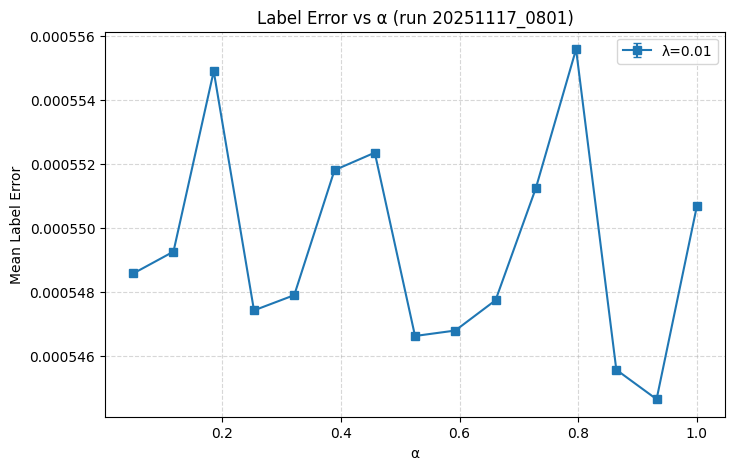

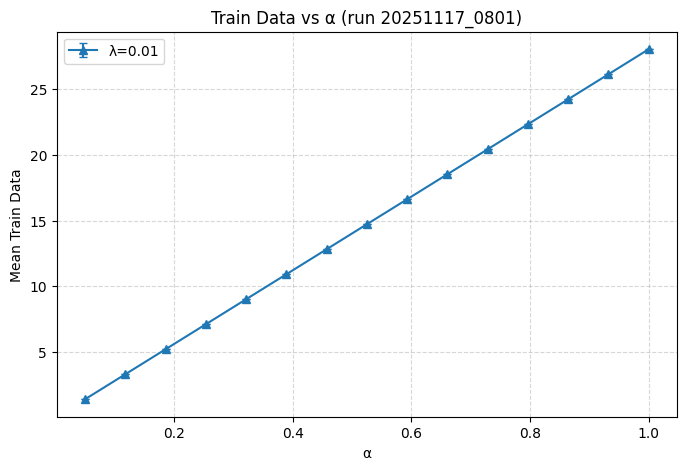

In [3]:
# --- Path to your local folder ---
base_path = f"../results/run_{run_id}/summary.csv"

# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- Plot Label Error vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["label_err_mean"], yerr=subset.get("label_err_std", 0),
                 marker='s', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Label Error")
plt.title(f"Label Error vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["train_data_mean"], yerr=subset.get("train_data_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Train Data")
plt.title(f"Train Data vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Results visualisation

Found 15 W_runs files.
Found 15 attn_run files.

[RUN] Processing ../results/run_20251117_0801/W_runs_0.pkl & ../results/run_20251117_0801/attn_run0.pkl (1 λ indices)


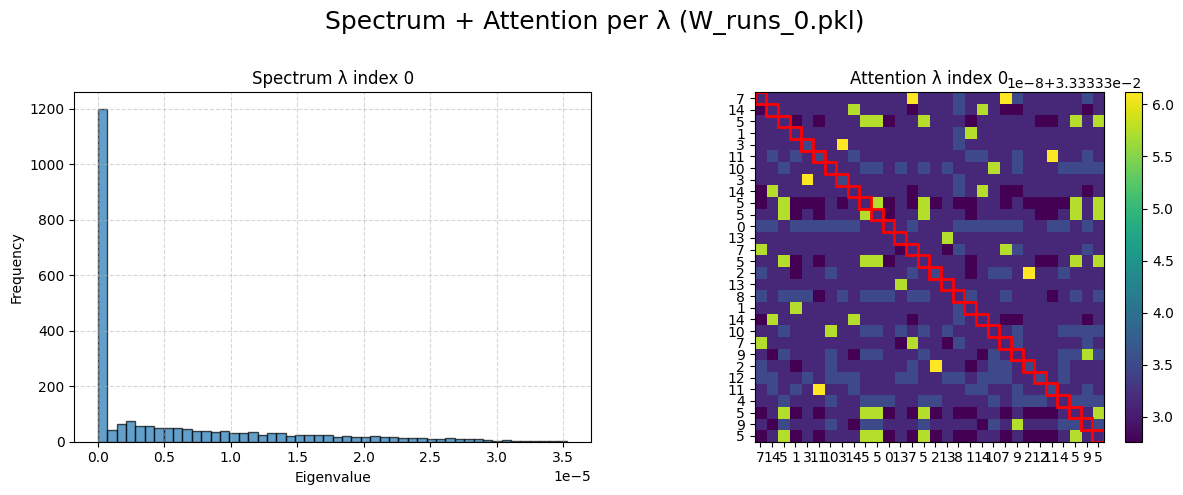


[RUN] Processing ../results/run_20251117_0801/W_runs_1.pkl & ../results/run_20251117_0801/attn_run1.pkl (1 λ indices)


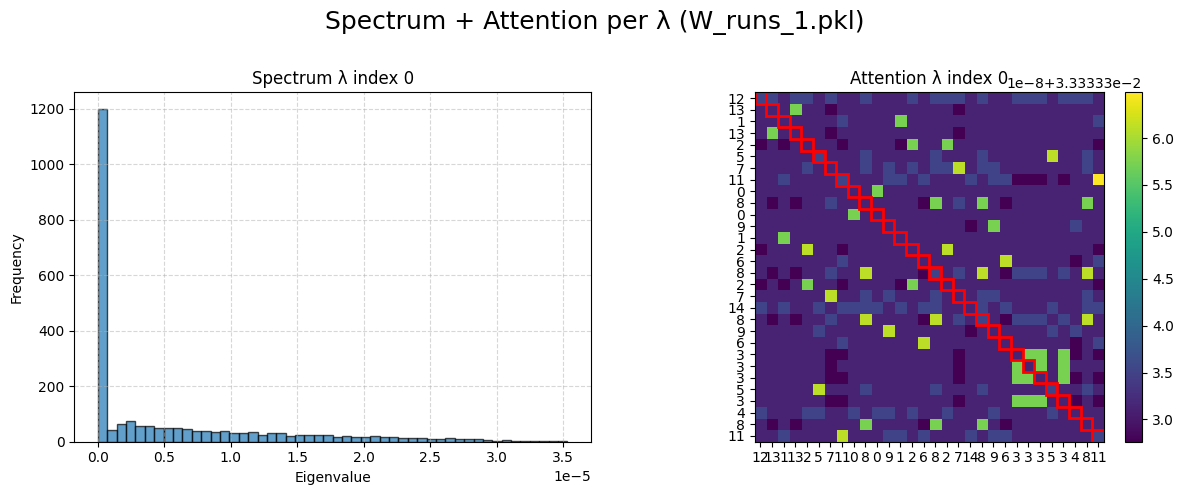


[RUN] Processing ../results/run_20251117_0801/W_runs_10.pkl & ../results/run_20251117_0801/attn_run10.pkl (1 λ indices)


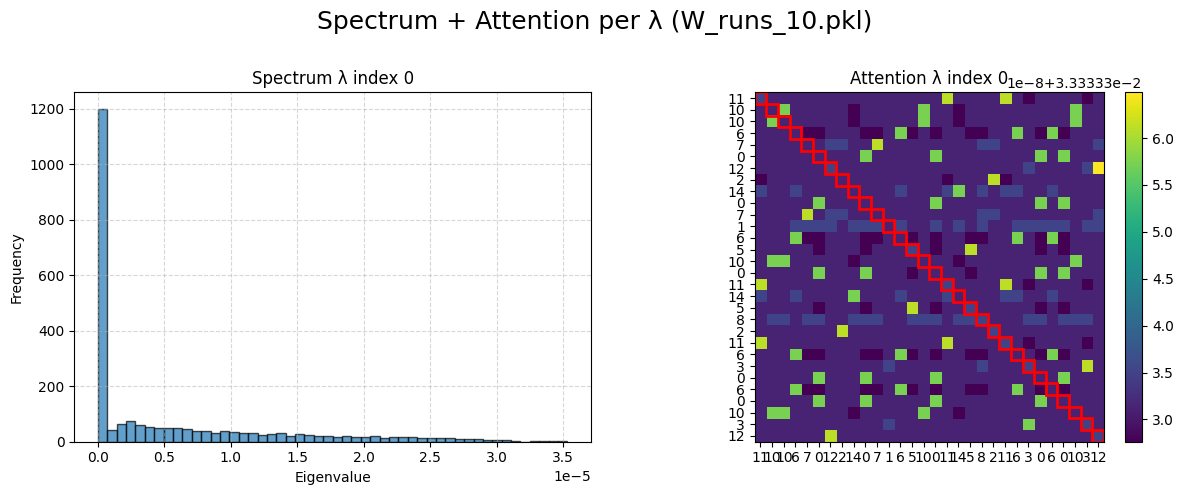


[RUN] Processing ../results/run_20251117_0801/W_runs_11.pkl & ../results/run_20251117_0801/attn_run11.pkl (1 λ indices)


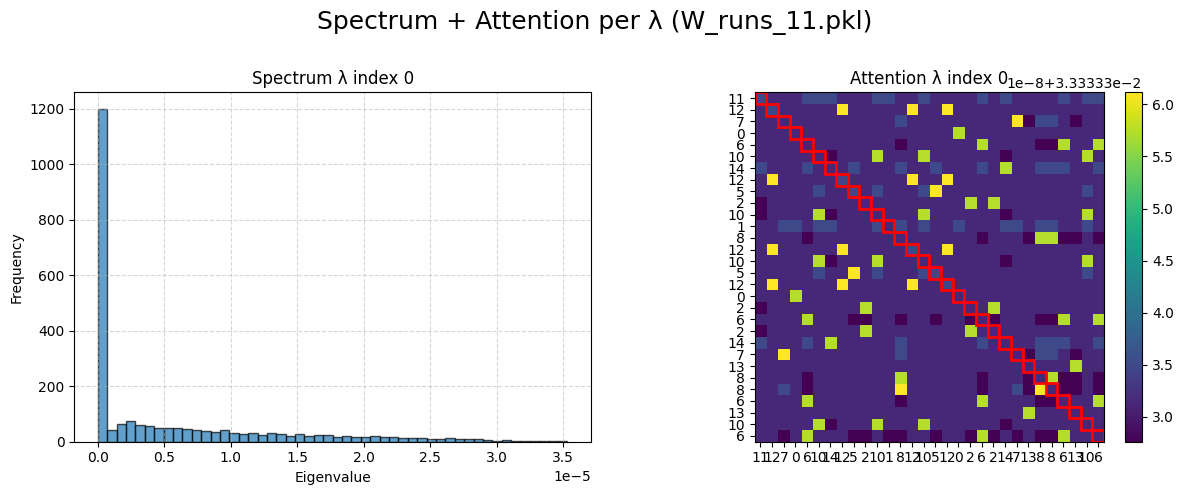


[RUN] Processing ../results/run_20251117_0801/W_runs_12.pkl & ../results/run_20251117_0801/attn_run12.pkl (1 λ indices)


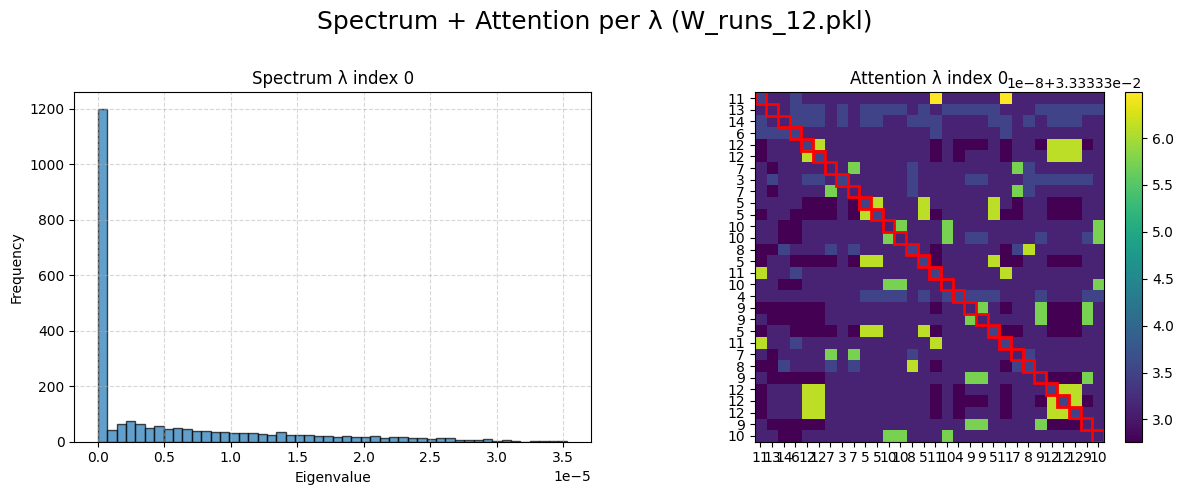


[RUN] Processing ../results/run_20251117_0801/W_runs_13.pkl & ../results/run_20251117_0801/attn_run13.pkl (1 λ indices)


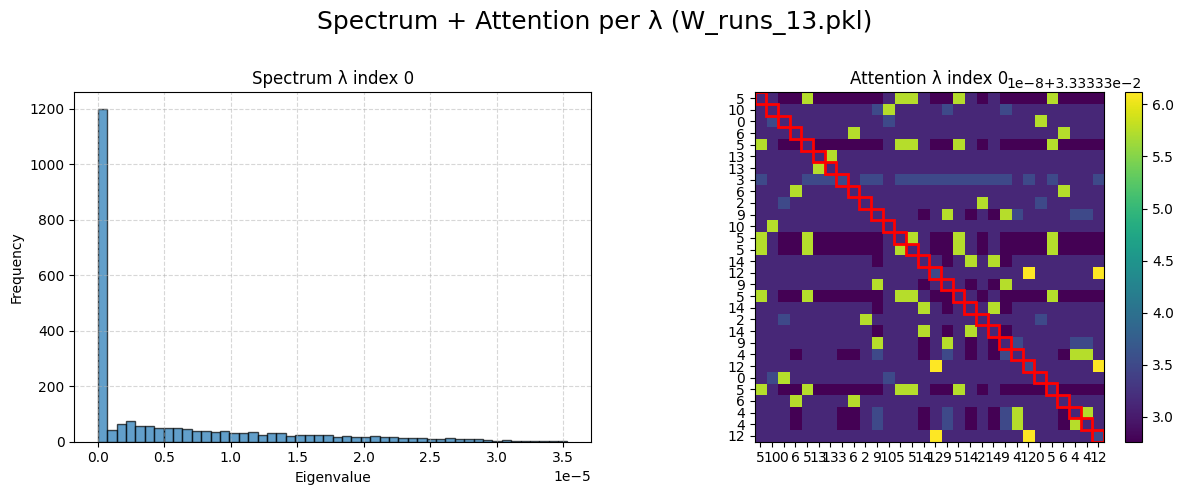


[RUN] Processing ../results/run_20251117_0801/W_runs_14.pkl & ../results/run_20251117_0801/attn_run14.pkl (1 λ indices)


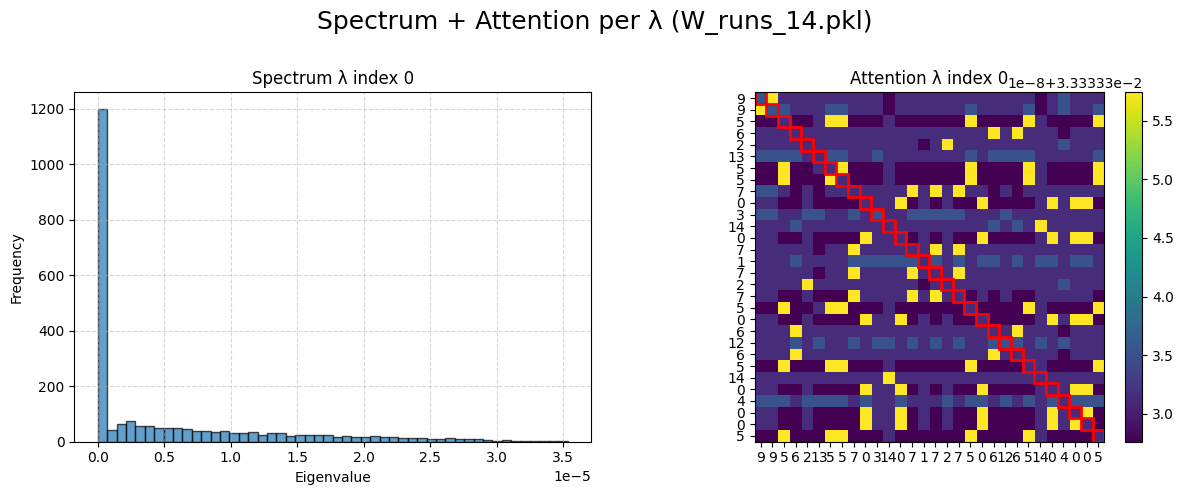


[RUN] Processing ../results/run_20251117_0801/W_runs_2.pkl & ../results/run_20251117_0801/attn_run2.pkl (1 λ indices)


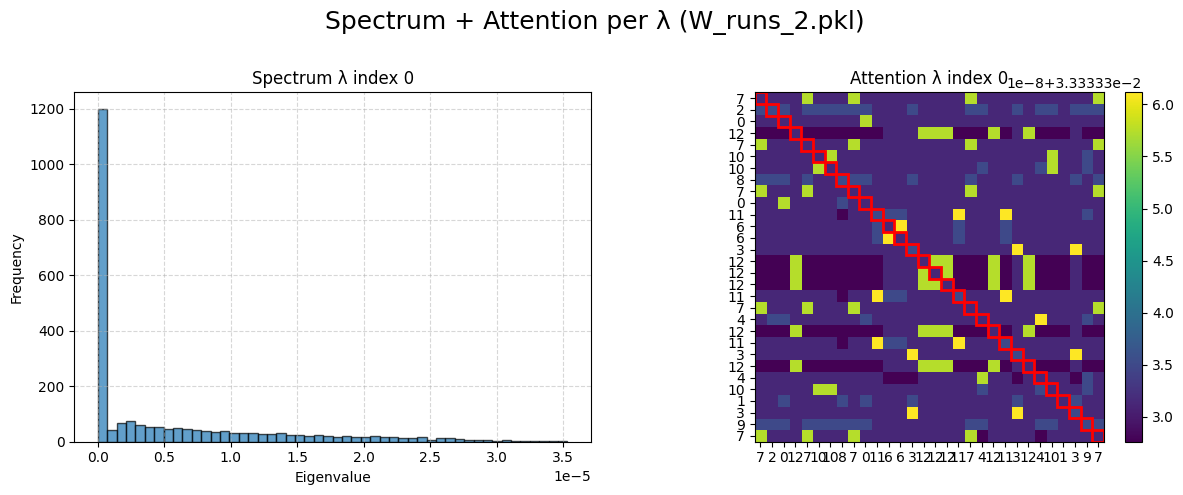


[RUN] Processing ../results/run_20251117_0801/W_runs_3.pkl & ../results/run_20251117_0801/attn_run3.pkl (1 λ indices)


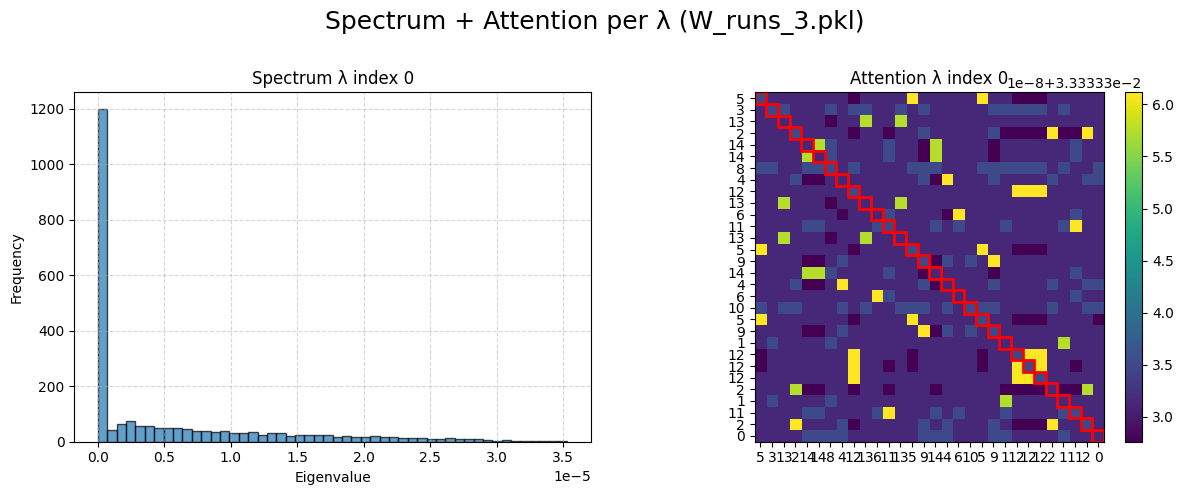


[RUN] Processing ../results/run_20251117_0801/W_runs_4.pkl & ../results/run_20251117_0801/attn_run4.pkl (1 λ indices)


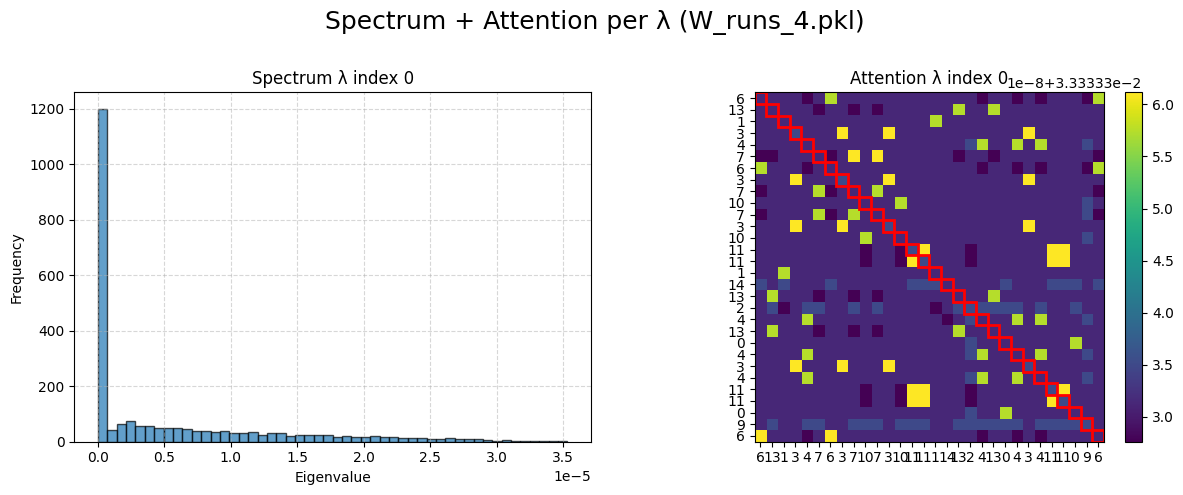


[RUN] Processing ../results/run_20251117_0801/W_runs_5.pkl & ../results/run_20251117_0801/attn_run5.pkl (1 λ indices)


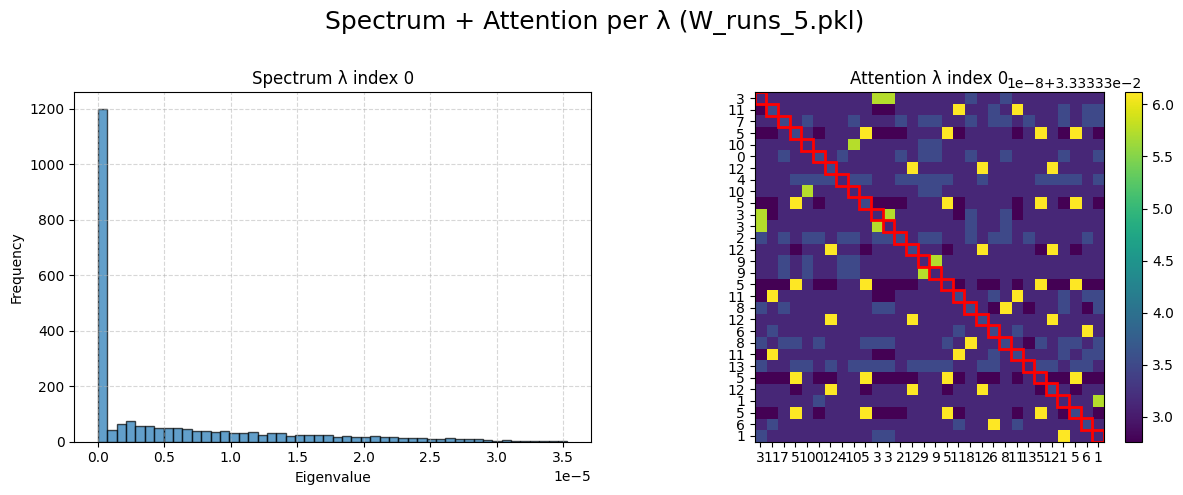


[RUN] Processing ../results/run_20251117_0801/W_runs_6.pkl & ../results/run_20251117_0801/attn_run6.pkl (1 λ indices)


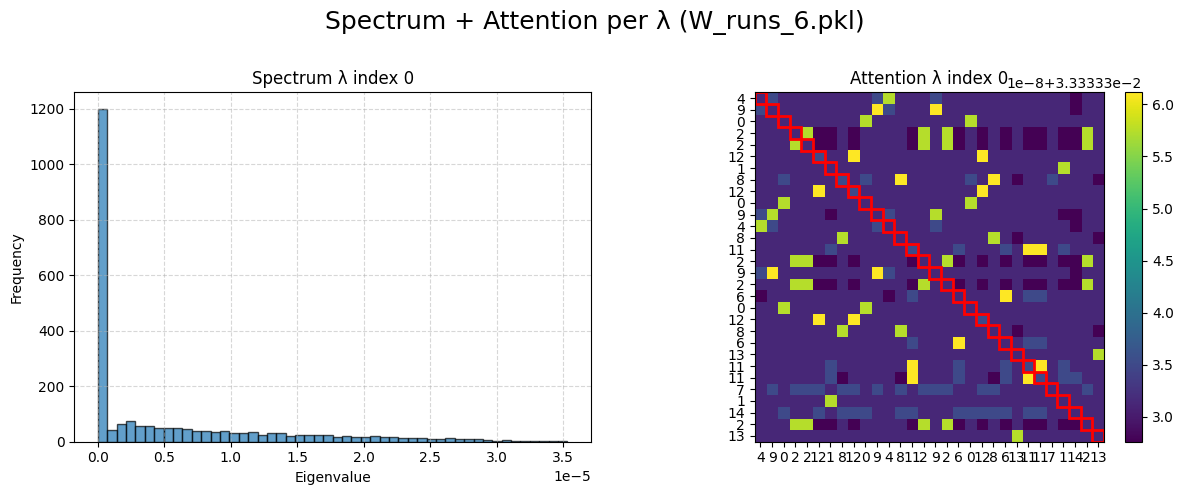


[RUN] Processing ../results/run_20251117_0801/W_runs_7.pkl & ../results/run_20251117_0801/attn_run7.pkl (1 λ indices)


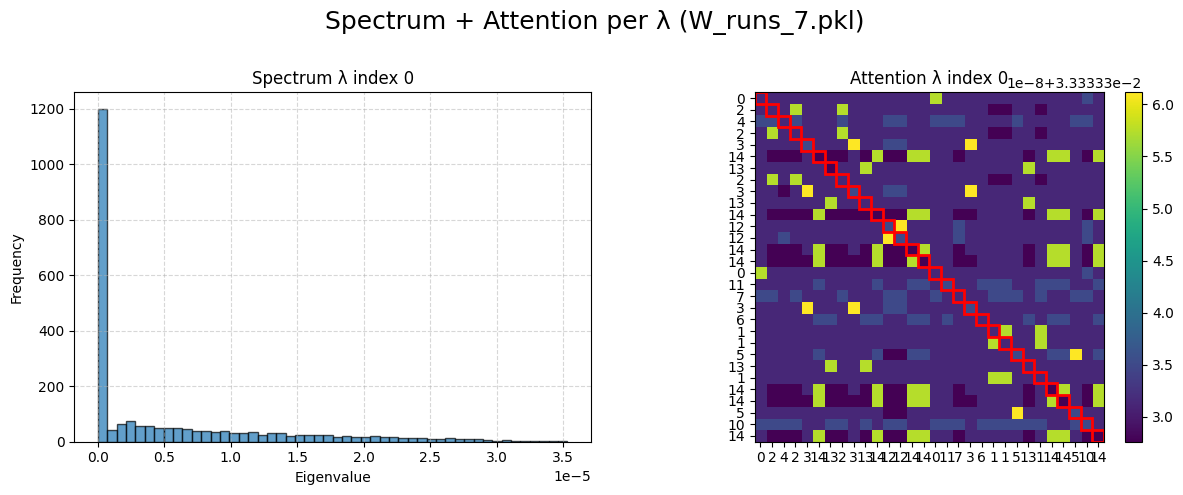


[RUN] Processing ../results/run_20251117_0801/W_runs_8.pkl & ../results/run_20251117_0801/attn_run8.pkl (1 λ indices)


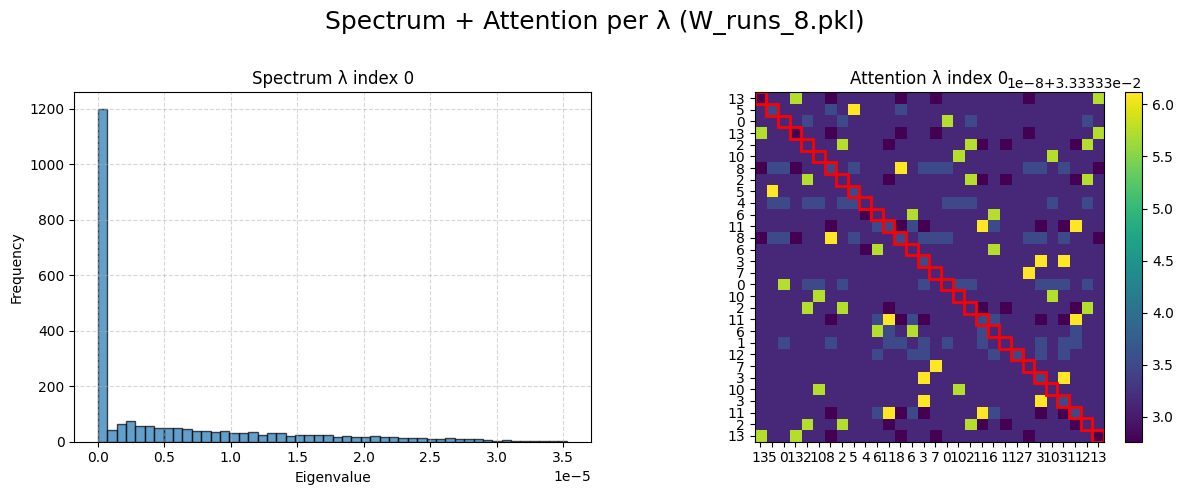


[RUN] Processing ../results/run_20251117_0801/W_runs_9.pkl & ../results/run_20251117_0801/attn_run9.pkl (1 λ indices)


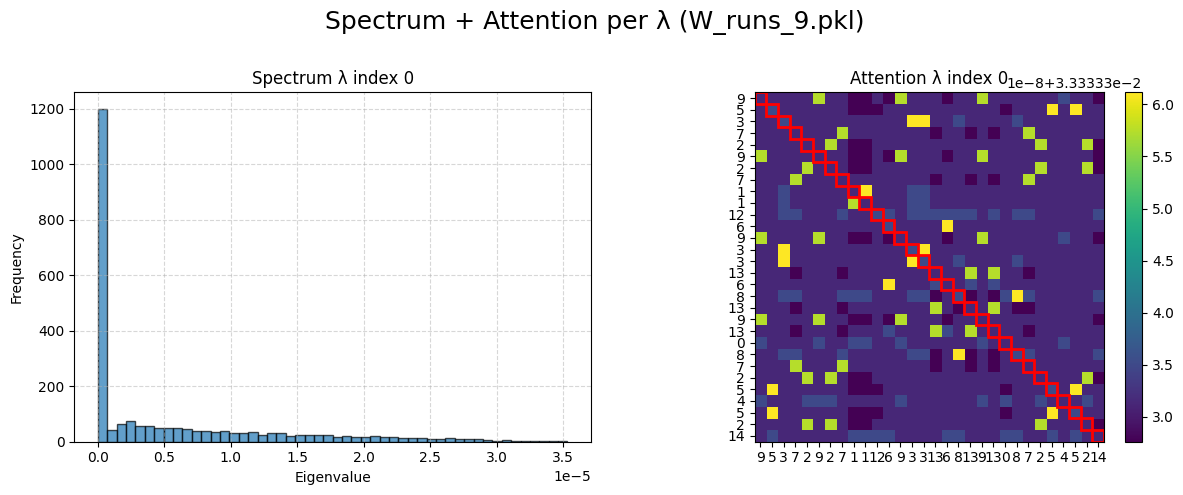

In [6]:
def highlight_diagonal(ax, seq_len, color='red', lw=2):
    """Draw red rectangles on the diagonal of a matrix plot"""
    for i in range(seq_len):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, color=color, lw=lw)
        ax.add_patch(rect)

# --- Path to your results directory ---
run_dir = f"../results/run_{run_id}"

# Load *both* types of files
W_files = sorted(glob.glob(os.path.join(run_dir, "W_runs_*.pkl")))
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_run*.pkl")))

print(f"Found {len(W_files)} W_runs files.")
print(f"Found {len(attn_files)} attn_run files.")

# --- Process each run synchronously ---
for W_file, attn_file in zip(W_files, attn_files):

    # ===== LOAD W spectrum data =====
    with open(W_file, "rb") as f:
        W_runs_all = pickle.load(f)  # list of length num_lambda

    num_lambda = len(W_runs_all)
    print(f"\n[RUN] Processing {W_file} & {attn_file} ({num_lambda} λ indices)")

    # ===== LOAD attention matrices =====
    with open(attn_file, "rb") as f:
        attn_data = pickle.load(f)

    attn_matrices = attn_data["attn_matrices"]
    seq_samples = attn_data["seq_samples"]

    # --- Use only min(len(attn_samples), num_lambda) to stay consistent
    n_plots = min(num_lambda, len(attn_matrices), 5)   # limit to 5 samples

    # Each λ → two plots → 2 columns
    fig, axes = plt.subplots(n_plots, 2, figsize=(12, 5*n_plots))

    if n_plots == 1:
        axes = np.array([axes])  # force 2D

    for i in range(n_plots):

        # ======== LEFT PLOT = Eigenvalue spectrum ========
        W_list = W_runs_all[i]
        eigvals_all = []

        for W in W_list:
            eigvals = np.linalg.eigvalsh(W @ W.T)  # Use eigvalsh for symmetric matrices - more stable (don't need constant factor)
            eigvals_all.extend(eigvals)

        eigvals_all = np.array(eigvals_all)

        ax_left = axes[i, 0]
        ax_left.hist(eigvals_all, bins=50, alpha=0.7, edgecolor='black')
        ax_left.set_title(f"Spectrum λ index {i}")
        ax_left.set_xlabel("Eigenvalue")
        ax_left.set_ylabel("Frequency")
        ax_left.grid(True, linestyle="--", alpha=0.5)

        # ======== RIGHT PLOT = Attention matrix ========
        attn_matrix_tensor = torch.tensor(attn_matrices[i])
        attn_matrix = attn_matrix_tensor[-1] if attn_matrix_tensor.ndim == 3 else attn_matrix_tensor
        
        seq_vals = np.array(seq_samples[i])
        if seq_vals.ndim == 2:
            seq_vals = seq_vals[-1]

        ax_right = axes[i, 1]
        im = ax_right.imshow(attn_matrix.numpy(), cmap='viridis')
        highlight_diagonal(ax_right, len(seq_vals))

        ax_right.set_xticks(np.arange(len(seq_vals)))
        ax_right.set_yticks(np.arange(len(seq_vals)))
        ax_right.set_xticklabels(seq_vals)
        ax_right.set_yticklabels(seq_vals)
        ax_right.set_title(f"Attention λ index {i}")

        fig.colorbar(im, ax=ax_right, fraction=0.046, pad=0.04)

    fig.suptitle(f"Spectrum + Attention per λ ({os.path.basename(W_file)})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()